## 📊 RQ2

How LLM perform in classifying obfuscation techniques?

In [1]:
# Imports
from   dotenv          		import load_dotenv
from   matplotlib      		import colors as mcolors
import matplotlib.pyplot 	as plt
import pandas          		as pd
import datetime
import json
import os

##### Initialization


In [2]:
print("⚡ START: {} ⚡".format(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")))
initTime = datetime.datetime.now()

⚡ START: 2026-06-11 11:12:51 ⚡


In [3]:
# Load .env Info
load_dotenv()

True

#### 📥 1] Load Data


Parameters

In [4]:
# LLM Models [TEST]
# MODELS = ["deepseek-r1_32b", "gpt-5-mini", "gemma3_27b", "qwen3_30b", "gpt-oss_20b"]

# Full Models
MODELS = ["gpt-4o-mini", "gpt-5-mini", "deepseek-r1_32b", "gemma3_27b", "qwen3_30b", "gpt-oss_20b"]

# Auto-discover every model that has results for all configured techniques.
# This is the default so RQ2 scales when more LLM result files are added.
MODELS = None

# Obfuscation Techniques [TEST]
# OBFUSCATION_TECHNIQUES  = ["ClassRename", "Reflection"]

# Full Techniques
OBFUSCATION_TECHNIQUES = ["ArithmeticBranch", "CallIndirection", "ClassRename", "ConstStringEncryption", "FieldRename", "Goto", "MethodOverload", "MethodRename", "Reflection"]

# Prompts
PROMPTS = ["ObfuscationClassificationV1"]

# Top-K values used to check whether the correct label is among the most frequent labels
TOP_K_VALUES = [1, 3, 5]

# Where results are stored
RESULTS_PATH = "../../0_Data/Results/"


Helpers

In [5]:
# Build file paths for results
def buildResultsFilePaths(resultsPath, promptId, techniqueDirName, modelName):
	basePath = os.path.join(resultsPath, promptId, techniqueDirName)
	csvPath  = os.path.join(basePath, "results_{}.csv".format(modelName))
	jsonPath = os.path.join(basePath, "results_{}.json".format(modelName))
	return csvPath, jsonPath

# Discover models from results_*.json/csv files. Only models present for every configured technique are kept.
def discoverModels(resultsPath, prompts, techniqueNames):
	modelsPerPrompt = {}
	for promptId in prompts:
		promptModels = None
		for techniqueDirName in techniqueNames:
			techniquePath = os.path.join(resultsPath, promptId, techniqueDirName)
			if not os.path.isdir(techniquePath):
				continue

			techniqueModels = set()
			for fileName in os.listdir(techniquePath):
				if fileName.startswith("results_") and (fileName.endswith(".json") or fileName.endswith(".csv")):
					modelName = fileName[len("results_"):].rsplit(".", 1)[0]
					techniqueModels.add(modelName)

			promptModels = techniqueModels if promptModels is None else promptModels.intersection(techniqueModels)

		modelsPerPrompt[promptId] = sorted(promptModels) if promptModels is not None else []

	discoveredModels = sorted(set().union(*modelsPerPrompt.values())) if len(modelsPerPrompt) > 0 else []
	return discoveredModels, modelsPerPrompt

# Load technique results into a DataFrame. JSON is preferred because it contains labelFrequency for top-k metrics.
def loadTechniqueResults(resultsPath, promptId, techniqueDirName, modelName):
	csvPath, jsonPath = buildResultsFilePaths(resultsPath, promptId, techniqueDirName, modelName)

	if os.path.exists(jsonPath):
		print("--- Loading JSON : {}".format(jsonPath))
		with open(jsonPath, "r") as inputFile:
			techniqueDf = pd.DataFrame(json.load(inputFile))
	elif os.path.exists(csvPath):
		print("--- Loading CSV  : {}".format(csvPath))
		techniqueDf = pd.read_csv(csvPath)
		techniqueDf["labelFrequency"] = [{} for _ in range(len(techniqueDf))]
	else:
		return None

	techniqueDf["obfuscationTechnique"] = techniqueDirName
	return techniqueDf

# Return labels sorted from most frequent to least frequent. Ties are deterministic.
def getRankedLabels(labelFrequency):
	if not isinstance(labelFrequency, dict):
		return []
	return [label for label, _ in sorted(labelFrequency.items(), key = lambda item: (-item[1], item[0]))]

# Compute best@1, best@3, and best@5 accuracy for a DataFrame of app results.
def computeClassificationMetrics(inputDf):
	workDf = inputDf.copy()
	workDf["isTop1Correct"] = workDf["expectedLabel"] == workDf["predictedBestLabel"]
	workDf["isTop3Correct"] = workDf.apply(lambda row: row["expectedLabel"] in row["top3Labels"], axis = 1)
	workDf["isTop5Correct"] = workDf.apply(lambda row: row["expectedLabel"] in row["top5Labels"], axis = 1)

	totalApps = len(workDf)
	return {
		"totalApps"      : totalApps,
		"bestAt1Correct" : int(workDf["isTop1Correct"].sum()),
		"bestAt3Correct" : int(workDf["isTop3Correct"].sum()),
		"bestAt5Correct" : int(workDf["isTop5Correct"].sum()),
		"bestAt1Accuracy": workDf["isTop1Correct"].mean() if totalApps > 0 else None,
		"bestAt3Accuracy": workDf["isTop3Correct"].mean() if totalApps > 0 else None,
		"bestAt5Accuracy": workDf["isTop5Correct"].mean() if totalApps > 0 else None,
	}

# Round metric columns to 2 decimal places
def roundMetricColumns(inputDf, metricColumns):
	outputDf = inputDf.copy()
	for metricColumn in metricColumns:
		if metricColumn in outputDf.columns:
			outputDf[metricColumn] = outputDf[metricColumn].round(2)
	return outputDf

Loading Data

In [6]:
# Build the summary, full category-level, and app-level DataFrames
summaryRows = []
fullRows    = []
appRows     = []
skippedRuns = []

if MODELS is None:
	MODELS, MODELS_BY_PROMPT = discoverModels(RESULTS_PATH, PROMPTS, OBFUSCATION_TECHNIQUES)
	print("--- 🔎 Auto-discovered models : {}".format(MODELS))
else:
	MODELS_BY_PROMPT = {promptId: MODELS for promptId in PROMPTS}

# For each model and prompt, load all technique folders and compute top-k classification accuracy.
for modelName in MODELS:
	for promptId in PROMPTS:
		if modelName not in MODELS_BY_PROMPT.get(promptId, MODELS):
			continue

		print('\n--- 🔍 Checking Combination : model={} | prompt={}'.format(modelName, promptId))
		resultsDfList        = []
		missingTechniqueDirs = []

		for techniqueDirName in OBFUSCATION_TECHNIQUES:
			techniqueDf = loadTechniqueResults(RESULTS_PATH, promptId, techniqueDirName, modelName)
			if techniqueDf is None:
				missingTechniqueDirs.append(techniqueDirName)
				continue
			resultsDfList.append(techniqueDf)

		if len(missingTechniqueDirs) > 0:
			print("--- ⚠️ Skipping combination. Missing techniques : {}".format(missingTechniqueDirs))
			skippedRuns.append({
				"model"               : modelName,
				"prompt"              : promptId,
				"missingTechniqueDirs" : ", ".join(missingTechniqueDirs)
			})
			continue

		resultsDf = pd.concat(resultsDfList, ignore_index = True)
		resultsDf = resultsDf[resultsDf["status"] == "SUCCESS"].copy()
		resultsDf["expectedLabel"] = resultsDf["obfuscationTechnique"]
		resultsDf["rankedLabels"]  = resultsDf["labelFrequency"].apply(getRankedLabels)
		resultsDf["predictedBestLabel"] = resultsDf["rankedLabels"].apply(lambda labels: labels[0] if len(labels) > 0 else None)
		resultsDf["top3Labels"] = resultsDf["rankedLabels"].apply(lambda labels: labels[:3])
		resultsDf["top5Labels"] = resultsDf["rankedLabels"].apply(lambda labels: labels[:5])
		resultsDf["top3LabelsText"] = resultsDf["top3Labels"].apply(lambda labels: ", ".join(labels))
		resultsDf["top5LabelsText"] = resultsDf["top5Labels"].apply(lambda labels: ", ".join(labels))
		resultsDf["isTop1Correct"] = resultsDf["expectedLabel"] == resultsDf["predictedBestLabel"]
		resultsDf["isTop3Correct"] = resultsDf.apply(lambda row: row["expectedLabel"] in row["top3Labels"], axis = 1)
		resultsDf["isTop5Correct"] = resultsDf.apply(lambda row: row["expectedLabel"] in row["top5Labels"], axis = 1)

		print("--- 📦 Loaded Apps : {}".format(len(resultsDf)))

		overallMetrics = computeClassificationMetrics(resultsDf)
		summaryRow = {
			"model"           : modelName,
			"prompt"          : promptId,
			"totalApps"       : overallMetrics["totalApps"],
			"bestAt1Correct"  : overallMetrics["bestAt1Correct"],
			"bestAt3Correct"  : overallMetrics["bestAt3Correct"],
			"bestAt5Correct"  : overallMetrics["bestAt5Correct"],
			"bestAt1Accuracy" : overallMetrics["bestAt1Accuracy"],
			"bestAt3Accuracy" : overallMetrics["bestAt3Accuracy"],
			"bestAt5Accuracy" : overallMetrics["bestAt5Accuracy"],
		}

		for techniqueDirName in OBFUSCATION_TECHNIQUES:
			techniqueDf      = resultsDf[resultsDf["obfuscationTechnique"] == techniqueDirName].copy()
			techniqueMetrics = computeClassificationMetrics(techniqueDf)

			summaryRow["BestAt1_{}".format(techniqueDirName)] = techniqueMetrics["bestAt1Accuracy"]
			summaryRow["BestAt3_{}".format(techniqueDirName)] = techniqueMetrics["bestAt3Accuracy"]
			summaryRow["BestAt5_{}".format(techniqueDirName)] = techniqueMetrics["bestAt5Accuracy"]

			fullRows.append({
				"model"           : modelName,
				"prompt"          : promptId,
				"category"        : techniqueDirName,
				"totalApps"       : techniqueMetrics["totalApps"],
				"bestAt1Correct"  : techniqueMetrics["bestAt1Correct"],
				"bestAt3Correct"  : techniqueMetrics["bestAt3Correct"],
				"bestAt5Correct"  : techniqueMetrics["bestAt5Correct"],
				"bestAt1Accuracy" : techniqueMetrics["bestAt1Accuracy"],
				"bestAt3Accuracy" : techniqueMetrics["bestAt3Accuracy"],
				"bestAt5Accuracy" : techniqueMetrics["bestAt5Accuracy"],
			})

		summaryRows.append(summaryRow)

		for _, appRow in resultsDf.iterrows():
			appRows.append({
				"model"              : modelName,
				"prompt"             : promptId,
				"sha256"             : appRow["sha256"],
				"pkgName"            : appRow["pkgName"],
				"expectedLabel"      : appRow["expectedLabel"],
				"predictedBestLabel" : appRow["predictedBestLabel"],
				"top3Labels"         : appRow["top3LabelsText"],
				"top5Labels"         : appRow["top5LabelsText"],
				"isTop1Correct"      : appRow["isTop1Correct"],
				"isTop3Correct"      : appRow["isTop3Correct"],
				"isTop5Correct"      : appRow["isTop5Correct"],
				"numSmaliClasses"    : appRow["numSmaliClasses"],
				"numSmaliClassesAnalyzed" : appRow["numSmaliClassesAnalyzed"],
			})

--- 🔎 Auto-discovered models : ['deepseek-r1_32b', 'gemma3_27b', 'gpt-4o-mini', 'gpt-5-mini', 'gpt-oss_20b', 'qwen3_30b']

--- 🔍 Checking Combination : model=deepseek-r1_32b | prompt=ObfuscationClassificationV1
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/ArithmeticBranch/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/CallIndirection/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/ClassRename/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/ConstStringEncryption/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/FieldRename/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/Goto/results_deepseek-r1_32b.json
--- Loading JSON : ../../0_Data/Results/ObfuscationClassificationV1/MethodOverload/results_deepseek-r1_32b.json
--- Loading

Save into DFs

In [7]:
# Convert rows into DataFrames and round metrics for readability.
summaryResultsDF = pd.DataFrame(summaryRows)
fullResultsDF    = pd.DataFrame(fullRows)
appResultsDF     = pd.DataFrame(appRows)
skippedRunsDf    = pd.DataFrame(skippedRuns)

summaryMetricColumns = [
	columnName for columnName in summaryResultsDF.columns
	if columnName.endswith("Accuracy") or columnName.startswith("BestAt1_") or columnName.startswith("BestAt3_") or columnName.startswith("BestAt5_")
]
fullMetricColumns = ["bestAt1Accuracy", "bestAt3Accuracy", "bestAt5Accuracy"]

summaryResultsDF = roundMetricColumns(summaryResultsDF, summaryMetricColumns)
fullResultsDF    = roundMetricColumns(fullResultsDF, fullMetricColumns)

print('\n--- 📊 summaryResultsDF Rows : {}'.format(len(summaryResultsDF)))
print("--- 📚 fullResultsDF Rows    : {}".format(len(fullResultsDF)))
print("--- 🧾 appResultsDF Rows     : {}".format(len(appResultsDF)))
print("--- ⚠️ Skipped Runs          : {}".format(len(skippedRunsDf)))




--- 📊 summaryResultsDF Rows : 6
--- 📚 fullResultsDF Rows    : 54
--- 🧾 appResultsDF Rows     : 540
--- ⚠️ Skipped Runs          : 0


In [8]:
summaryResultsDF

,model,prompt,totalApps,bestAt1Correct,bestAt3Correct,bestAt5Correct,bestAt1Accuracy,bestAt3Accuracy,bestAt5Accuracy,BestAt1_ArithmeticBranch,...,BestAt5_Goto,BestAt1_MethodOverload,BestAt3_MethodOverload,BestAt5_MethodOverload,BestAt1_MethodRename,BestAt3_MethodRename,BestAt5_MethodRename,BestAt1_Reflection,BestAt3_Reflection,BestAt5_Reflection
0,deepseek-r1_32b,ObfuscationClassificationV1,90,52,69,78,0.58,0.77,0.87,0.55,...,1.0,0.4,0.7,1.0,0.6,1.0,1.0,0.22,0.44,0.56
1,gemma3_27b,ObfuscationClassificationV1,90,42,67,81,0.47,0.74,0.90,0.36,...,1.0,0.1,0.5,1.0,0.9,1.0,1.0,0.00,0.11,0.56
2,gpt-4o-mini,ObfuscationClassificationV1,90,64,83,87,0.71,0.92,0.97,0.82,...,1.0,0.7,1.0,1.0,0.8,1.0,1.0,0.22,0.56,0.67
3,gpt-5-mini,ObfuscationClassificationV1,90,76,85,87,0.84,0.94,0.97,0.91,...,1.0,0.8,1.0,1.0,0.8,1.0,1.0,0.33,0.44,0.67
4,gpt-oss_20b,ObfuscationClassificationV1,90,66,85,86,0.73,0.94,0.96,0.91,...,1.0,0.7,1.0,1.0,0.8,1.0,1.0,0.33,0.44,0.56
5,qwen3_30b,ObfuscationClassificationV1,90,64,76,85,0.71,0.84,0.94,0.91,...,1.0,0.7,1.0,1.0,0.8,1.0,1.0,0.22,0.33,0.44


In [9]:
fullResultsDF.head()

,model,prompt,category,totalApps,bestAt1Correct,bestAt3Correct,bestAt5Correct,bestAt1Accuracy,bestAt3Accuracy,bestAt5Accuracy
0,deepseek-r1_32b,ObfuscationClassificationV1,ArithmeticBranch,11,6,10,11,0.55,0.91,1.0
1,deepseek-r1_32b,ObfuscationClassificationV1,CallIndirection,10,0,0,2,0.00,0.00,0.2
2,deepseek-r1_32b,ObfuscationClassificationV1,ClassRename,10,10,10,10,1.00,1.00,1.0
3,deepseek-r1_32b,ObfuscationClassificationV1,ConstStringEncryption,10,9,10,10,0.90,1.00,1.0
4,deepseek-r1_32b,ObfuscationClassificationV1,FieldRename,10,5,8,10,0.50,0.80,1.0


💾 #### 2] Save results into CSV files 

In [10]:
# Save summary and category-level CSVs
summaryCsvPath = "RQ2_summaryResults.csv"
fullCsvPath    = "RQ2_fullResults.csv"

summaryResultsDF.to_csv(summaryCsvPath, index = False, na_rep = "NaN")
fullResultsDF.to_csv(fullCsvPath, index = False, na_rep = "NaN")
print("--- 💾 summaryResultsDF saved : {}".format(summaryCsvPath))
print("--- 💾 fullResultsDF saved    : {}".format(fullCsvPath))


--- 💾 summaryResultsDF saved : RQ2_summaryResults.csv
--- 💾 fullResultsDF saved    : RQ2_fullResults.csv


### 3] Plots 📈

Parameters and Utils

In [11]:
# Parameters
SMALL_SIZE  = 14
MEDIUM_SIZE = 16
LARGE_SIZE  = 18

# Plotting parameters
PLOT_FIGSIZE          = (10, 6)
COMBINED_PLOT_FIGSIZE = (10, 6)
CATEGORY_PLOT_FIGSIZE = (16, 7)
LEGEND_FONT_SIZE      = 11
TITLE_PAD             = 18

# Font setup
plt.rc("font", size = SMALL_SIZE)
plt.rc("axes", titlesize = LARGE_SIZE, labelsize = MEDIUM_SIZE)
plt.rc("xtick", labelsize = SMALL_SIZE)
plt.rc("ytick", labelsize = SMALL_SIZE)
plt.rc("legend", fontsize = SMALL_SIZE)
plt.rc("figure", titlesize = LARGE_SIZE)

# Colors
COLORS = ["#89CFFD", "#FFCB42", "#68B984", "#BFACE2", "#F0A04B", "#5DA7DB", "#E96479", "#FF9A9A", "#A55B4B"]

METRIC_COLUMNS = ["bestAt1Accuracy", "bestAt3Accuracy", "bestAt5Accuracy"]
METRIC_LABELS  = ["Best@1", "Best@3", "Best@5"]
METRIC_LABEL_BY_COLUMN = dict(zip(METRIC_COLUMNS, METRIC_LABELS))
METRIC_ORDER_DF = pd.DataFrame({"metric": METRIC_COLUMNS, "metricLabel": METRIC_LABELS, "topK": TOP_K_VALUES})

TRAFFIC_LIGHT_CMAP = mcolors.LinearSegmentedColormap.from_list(
	"traffic_light",
	[COLORS[6], COLORS[1], COLORS[2]]
)

PROMPT_STYLES = [
	{"linestyle": "-",  "marker": "o"},
	{"linestyle": "--", "marker": "s"},
	{"linestyle": ":",  "marker": "^"},
	{"linestyle": "-.", "marker": "D"},
	{"linestyle": (0, (3, 1, 1, 1)), "marker": "P"}
]

def getPromptStyle(promptIndex):
	return PROMPT_STYLES[promptIndex % len(PROMPT_STYLES)]

def buildTechniqueColors(techniqueNames):
	return {
		techniqueName: COLORS[(index + 2) % len(COLORS)]
		for index, techniqueName in enumerate(techniqueNames)
	}

def fillNaForPlotting(inputDf, metricColumns):
	plotDf = inputDf.copy()
	for metricColumn in metricColumns:
		if metricColumn in plotDf.columns:
			plotDf[metricColumn] = plotDf[metricColumn].fillna(0)
	return plotDf

def meltAccuracyDf(inputDf, idColumns):
	meltedDf = inputDf.melt(id_vars = idColumns, value_vars = METRIC_COLUMNS, var_name = "metric", value_name = "accuracy")
	meltedDf = meltedDf.merge(METRIC_ORDER_DF, on = "metric", how = "left")
	return meltedDf.sort_values(idColumns + ["topK"]).reset_index(drop = True)

def plotMetricHeatmap(inputDf, indexColumn, columnsColumn, metricColumn, title, xLabel, yLabel, colorBarLabel):
	plotDf = fillNaForPlotting(inputDf, [metricColumn])
	heatmapDf = plotDf.pivot(index = indexColumn, columns = columnsColumn, values = metricColumn)

	fig, ax = plt.subplots(figsize = (12, max(3.5, len(heatmapDf.index) * 1.0)))
	image = ax.imshow(heatmapDf.values, cmap = TRAFFIC_LIGHT_CMAP, vmin = 0, vmax = 1, aspect = "auto")

	ax.set_title(title, pad = TITLE_PAD)
	ax.set_xlabel(xLabel)
	ax.set_ylabel(yLabel)
	ax.set_xticks(range(len(heatmapDf.columns)))
	ax.set_xticklabels(heatmapDf.columns)
	ax.set_yticks(range(len(heatmapDf.index)))
	ax.set_yticklabels(heatmapDf.index)

	for rowIndex in range(len(heatmapDf.index)):
		for columnIndex in range(len(heatmapDf.columns)):
			cellValue = heatmapDf.iloc[rowIndex, columnIndex]
			cellText = "-" if pd.isna(cellValue) else "{:.2f}".format(cellValue)
			textColor = "black" if pd.isna(cellValue) else "white"
			ax.text(columnIndex, rowIndex, cellText, ha = "center", va = "center", color = textColor, fontsize = 12, fontweight = "bold")

	colorBar = fig.colorbar(image, ax = ax)
	colorBar.set_label(colorBarLabel)

	ax.set_xticks([tick - 0.5 for tick in range(1, len(heatmapDf.columns))], minor = True)
	ax.set_yticks([tick - 0.5 for tick in range(1, len(heatmapDf.index))], minor = True)
	ax.grid(which = "minor", color = "white", linestyle = "-", linewidth = 2)
	ax.tick_params(which = "minor", bottom = False, left = False)
	plt.tight_layout()
	plt.show()


#### 🔷 A] Averaged Classification Accuracy

⭕ Combination:
- [LLM]
- AVG over all [Techniques]

⭕ Showing:
- X Axis: [Best@1], [Best@3], [Best@5]
- Bars: [LLM]
- Y Axis: [Accuracy]


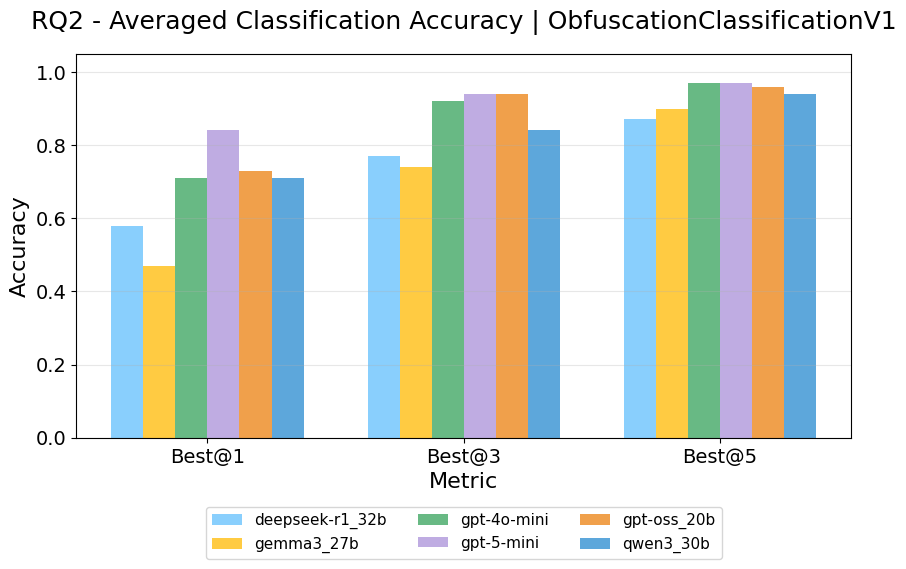

In [12]:
# One averaged grouped bar plot for each prompt.
# X ticks are Best@K metrics; each LLM is a differently colored bar.
summaryLongDf = meltAccuracyDf(summaryResultsDF, ["model", "prompt"])

for promptId in PROMPTS:
	promptPlotDf = summaryLongDf[summaryLongDf["prompt"] == promptId].copy()
	if promptPlotDf.empty:
		continue

	availableModels = [modelName for modelName in MODELS if modelName in promptPlotDf["model"].unique()]
	barWidth        = min(0.22, 0.75 / max(1, len(availableModels)))
	xPositions      = range(len(METRIC_LABELS))

	plt.figure(figsize = COMBINED_PLOT_FIGSIZE)
	for modelIndex, modelName in enumerate(availableModels):
		modelPlotDf = promptPlotDf[promptPlotDf["model"] == modelName].sort_values("topK")
		values      = [modelPlotDf[modelPlotDf["metric"] == metricColumn]["accuracy"].iloc[0] for metricColumn in METRIC_COLUMNS]
		offsets     = [position + (modelIndex - (len(availableModels) - 1) / 2) * barWidth for position in xPositions]
		plt.bar(offsets, values, width = barWidth, color = COLORS[(modelIndex) % len(COLORS)], label = modelName)

	plt.title("RQ2 - Averaged Classification Accuracy | {}".format(promptId), pad = TITLE_PAD)
	plt.xlabel("Metric")
	plt.ylabel("Accuracy")
	plt.xticks(list(xPositions), METRIC_LABELS)
	plt.ylim(0, 1.05)
	plt.grid(axis = "y", alpha = 0.3)
	plt.legend(loc = "upper center", bbox_to_anchor = (0.5, -0.16), ncol = min(3, max(1, len(availableModels))), fontsize = LEGEND_FONT_SIZE)
	plt.subplots_adjust(bottom = 0.24)
	plt.show()


#### 🔷 B] Per-Category Classification Accuracy

⭕ Combination:
- [LLM]

⭕ Showing:
- X Axis: [Technique]
- Y Axis: [Best@1], [Best@3], [Best@5]


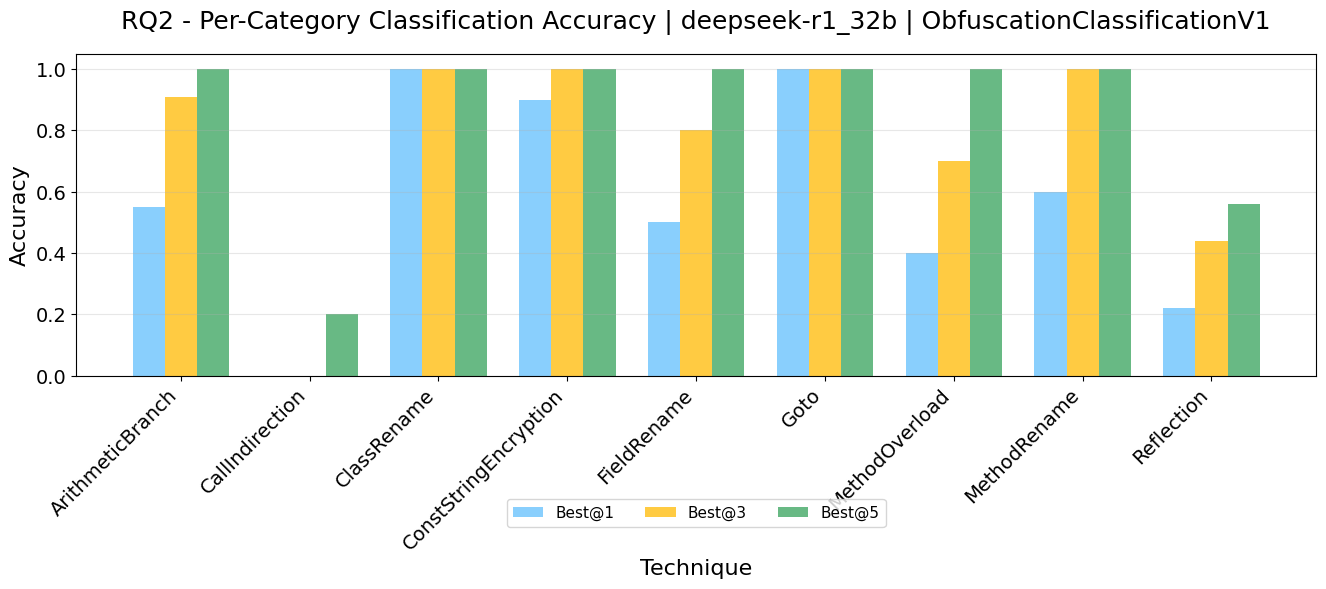

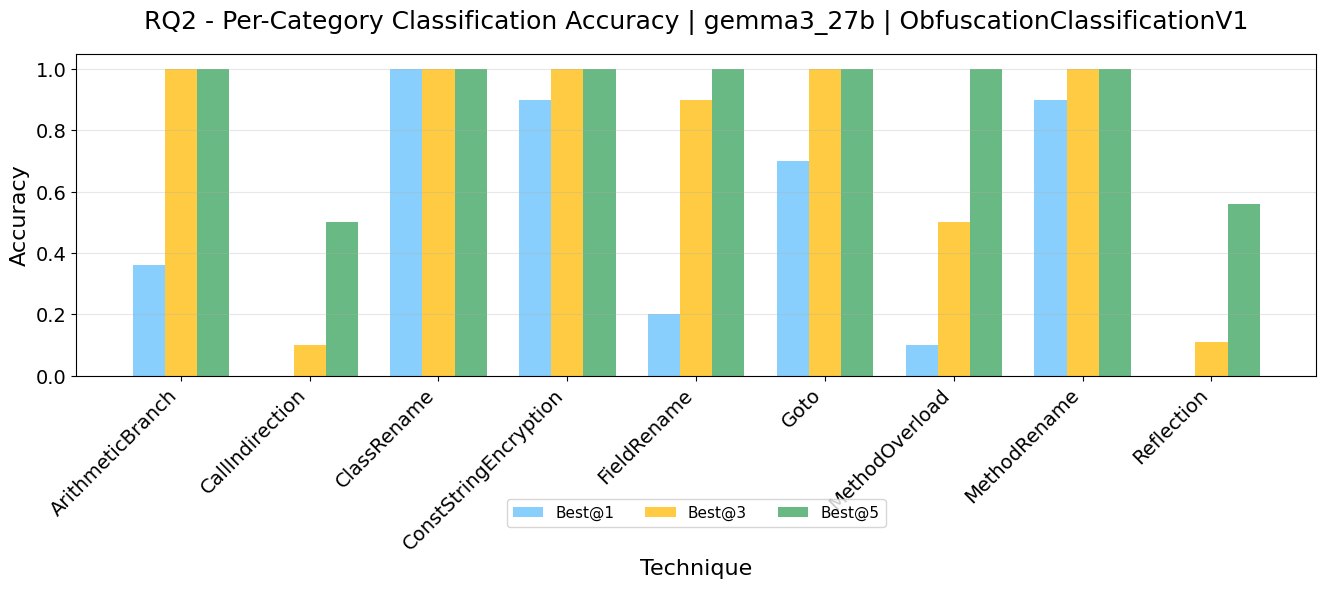

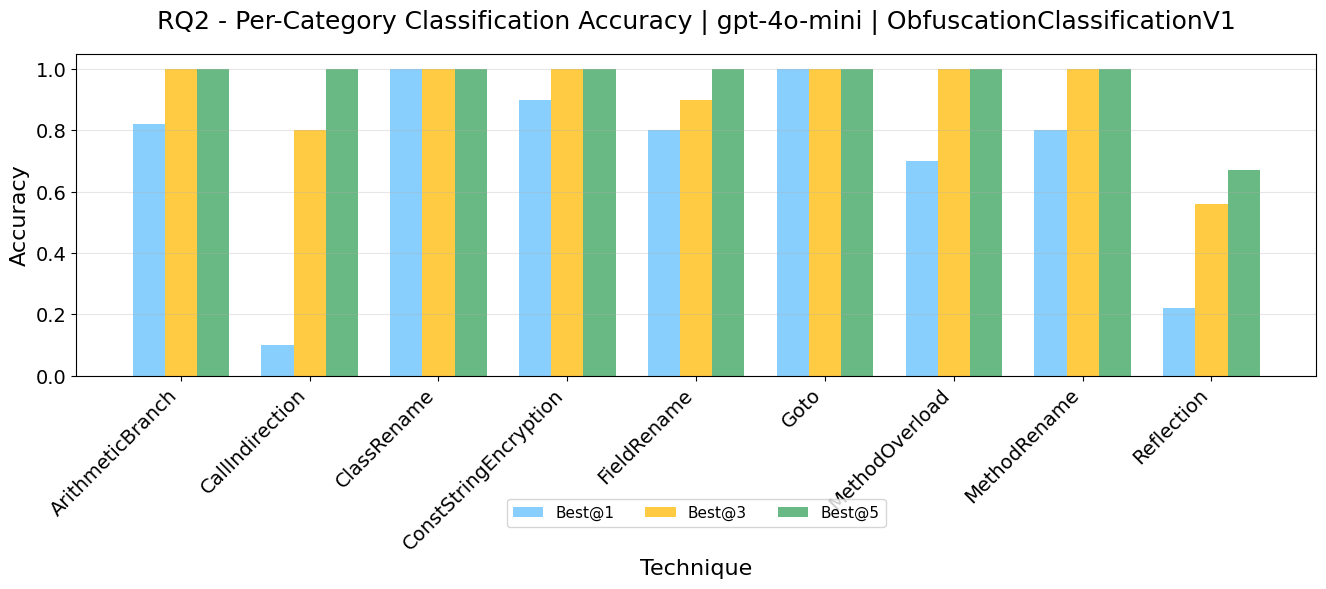

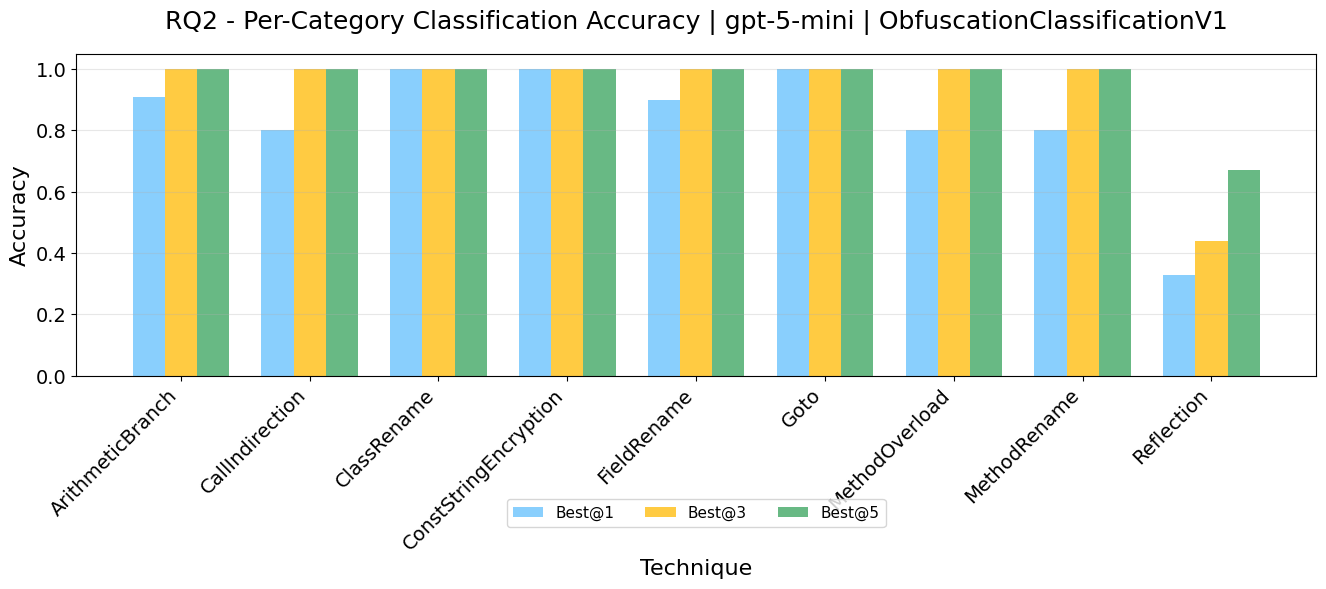

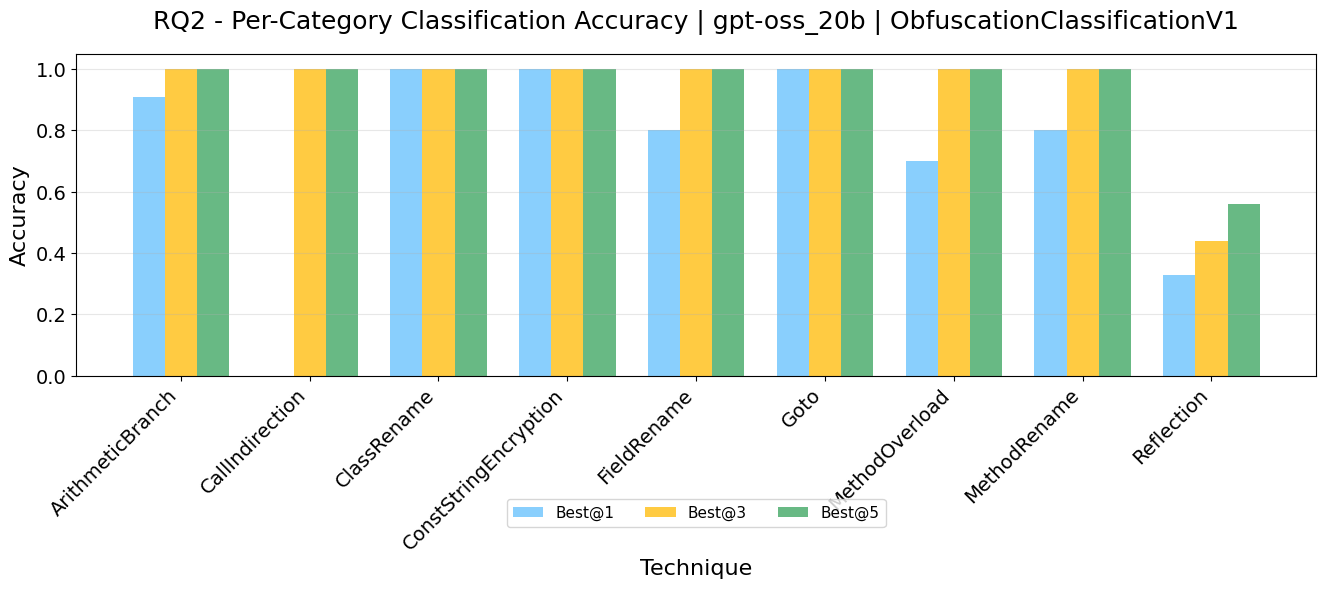

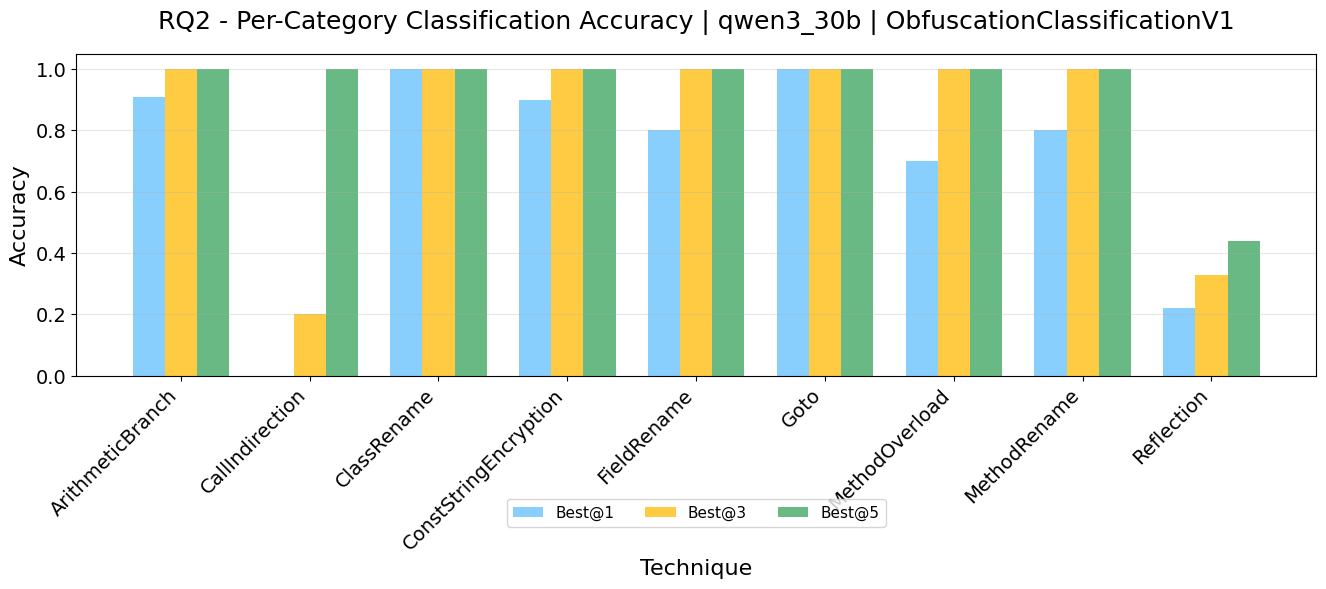

In [13]:
# One per-category grouped bar plot for each prompt-model combination.
fullLongDf = meltAccuracyDf(fullResultsDF, ["model", "prompt", "category"])
plotCombinationsDf = summaryResultsDF[["model", "prompt"]].drop_duplicates().reset_index(drop = True)
barWidth = 0.25

for _, combinationRow in plotCombinationsDf.iterrows():
	modelName = combinationRow["model"]
	promptId  = combinationRow["prompt"]
	plotDf    = fullResultsDF[(fullResultsDF["model"] == modelName) & (fullResultsDF["prompt"] == promptId)].copy()
	if plotDf.empty:
		continue

	plotDf["category"] = pd.Categorical(plotDf["category"], categories = OBFUSCATION_TECHNIQUES, ordered = True)
	plotDf = plotDf.sort_values("category")
	xPositions = range(len(plotDf))

	plt.figure(figsize = CATEGORY_PLOT_FIGSIZE)
	for metricIndex, metricColumn in enumerate(METRIC_COLUMNS):
		offsets = [position + (metricIndex - 1) * barWidth for position in xPositions]
		plt.bar(offsets, plotDf[metricColumn], width = barWidth, color = COLORS[(metricIndex) % len(COLORS)], label = METRIC_LABEL_BY_COLUMN[metricColumn])

	plt.title("RQ2 - Per-Category Classification Accuracy | {} | {}".format(modelName, promptId), pad = TITLE_PAD)
	plt.xlabel("Technique")
	plt.ylabel("Accuracy")
	plt.xticks(list(xPositions), plotDf["category"], rotation = 45, ha = "right")
	plt.ylim(0, 1.05)
	plt.grid(axis = "y", alpha = 0.3)
	plt.legend(loc = "upper center", bbox_to_anchor = (0.5, -0.36), ncol = 3, fontsize = LEGEND_FONT_SIZE)
	plt.subplots_adjust(bottom = 0.42)
	plt.show()


#### 🔷 C] Accuracy by LLM


⭕ Showing:
- X Axis: [LLM]
- Y Axis: [Best@1], [Best@3], [Best@5]

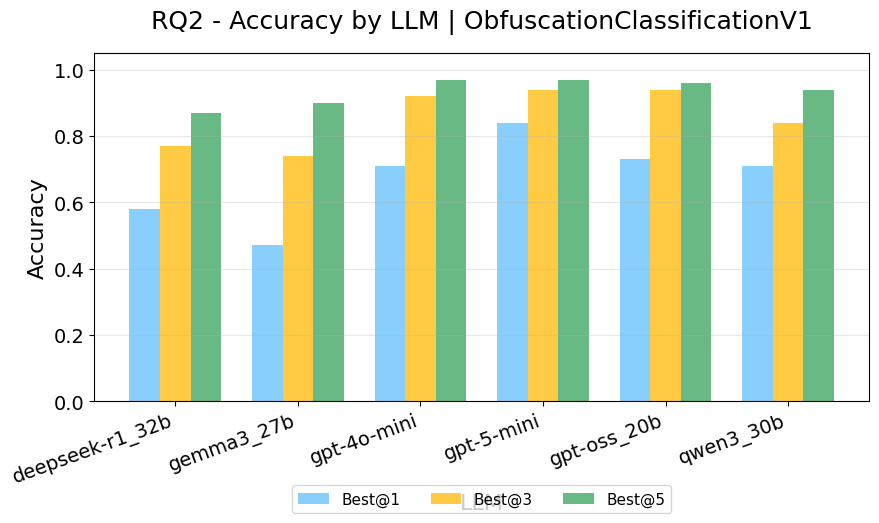

In [14]:
# One grouped bar plot for each prompt with one group per model.
barWidth = 0.25

for promptId in PROMPTS:
	promptPlotDf = summaryResultsDF[summaryResultsDF["prompt"] == promptId].copy()
	if promptPlotDf.empty:
		continue

	availableModels = [modelName for modelName in MODELS if modelName in promptPlotDf["model"].unique()]
	xPositions = range(len(availableModels))

	plt.figure(figsize = COMBINED_PLOT_FIGSIZE)
	for metricIndex, metricColumn in enumerate(METRIC_COLUMNS):
		values = [promptPlotDf[promptPlotDf["model"] == modelName].iloc[0][metricColumn] for modelName in availableModels]
		offsets = [position + (metricIndex - 1) * barWidth for position in xPositions]
		plt.bar(offsets, values, width = barWidth, color = COLORS[(metricIndex) % len(COLORS)], label = METRIC_LABEL_BY_COLUMN[metricColumn])

	plt.title("RQ2 - Accuracy by LLM | {}".format(promptId), pad = TITLE_PAD)
	plt.xlabel("LLM")
	plt.ylabel("Accuracy")
	plt.xticks(list(xPositions), availableModels, rotation = 20, ha = "right")
	plt.ylim(0, 1.05)
	plt.grid(axis = "y", alpha = 0.3)
	plt.legend(loc = "upper center", bbox_to_anchor = (0.5, -0.22), ncol = 3, fontsize = LEGEND_FONT_SIZE)
	plt.subplots_adjust(bottom = 0.30)
	plt.show()


#### 🔥 D] Per-Category Heatmaps

Combination:
- [LLM] x [PROMPT]

Showing:
- X Axis: [Top-K metric]
- Y Axis: [Technique]
- Cell: [Accuracy]

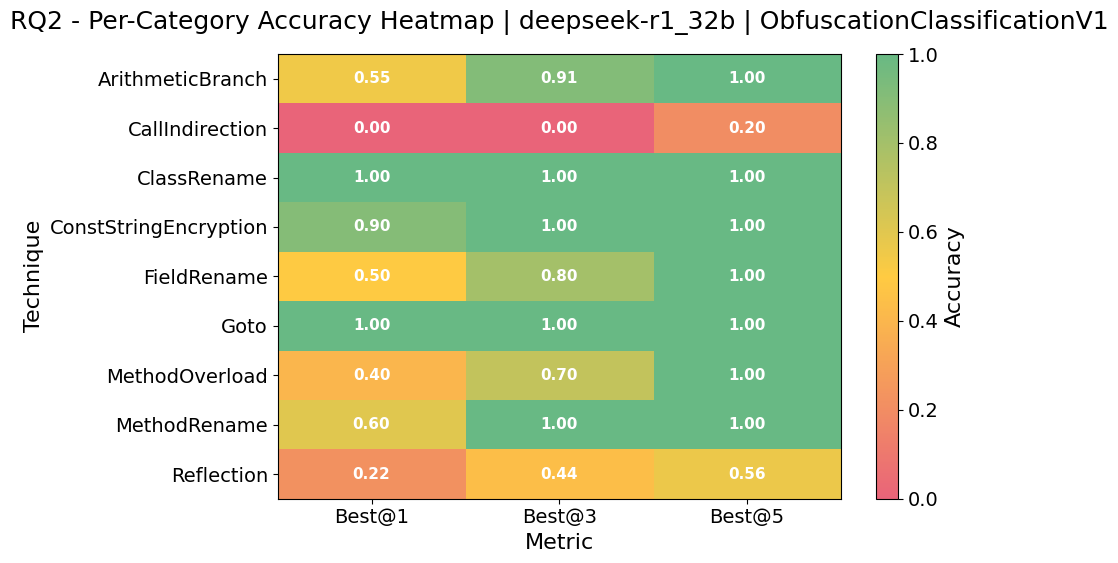

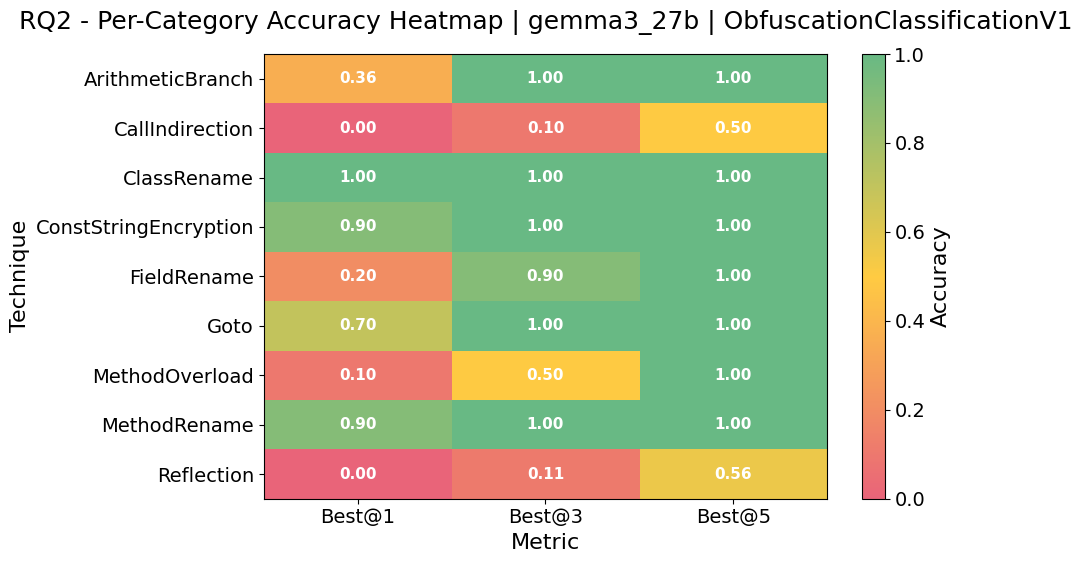

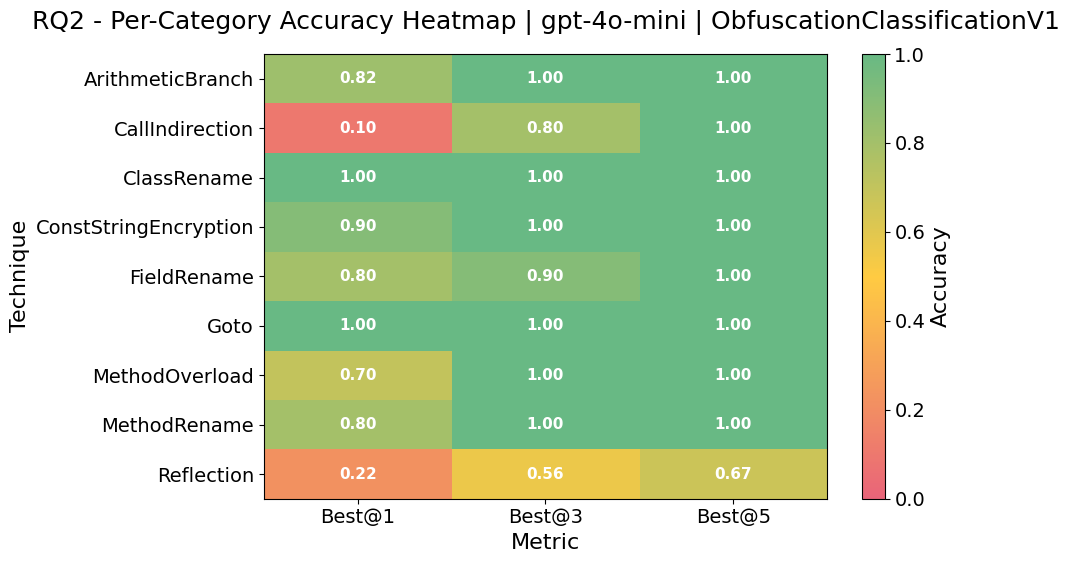

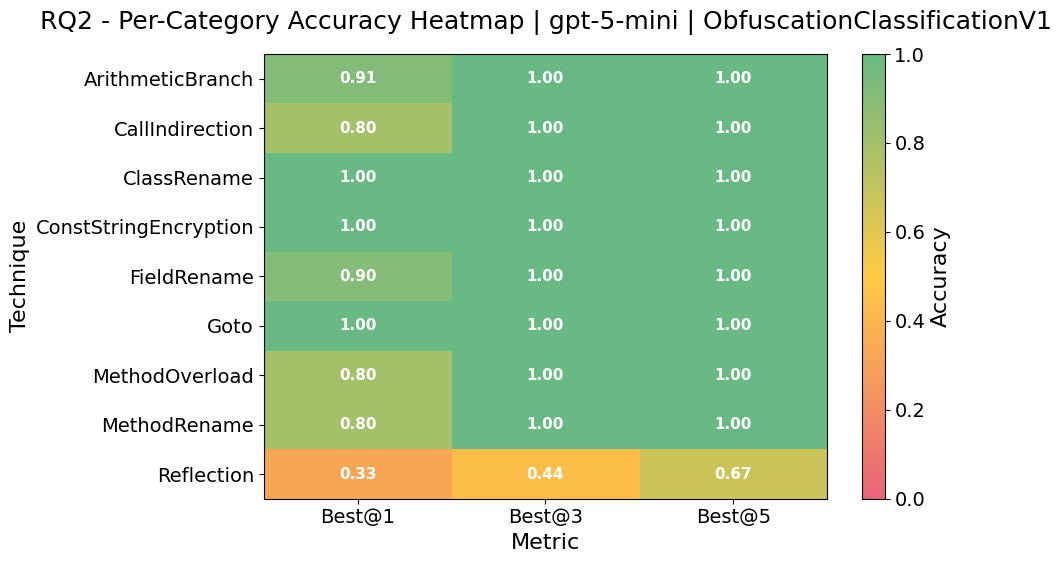

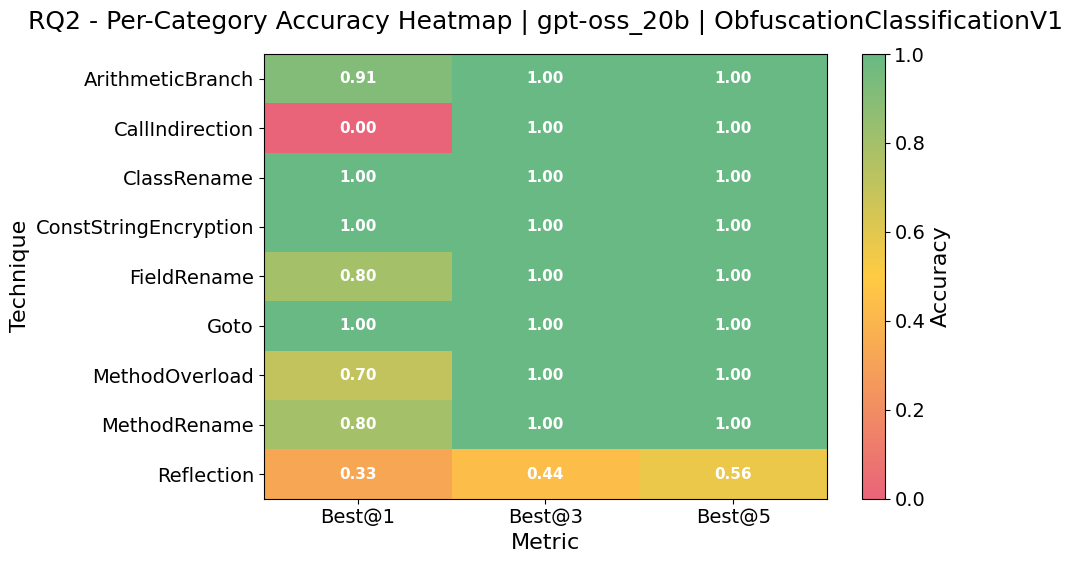

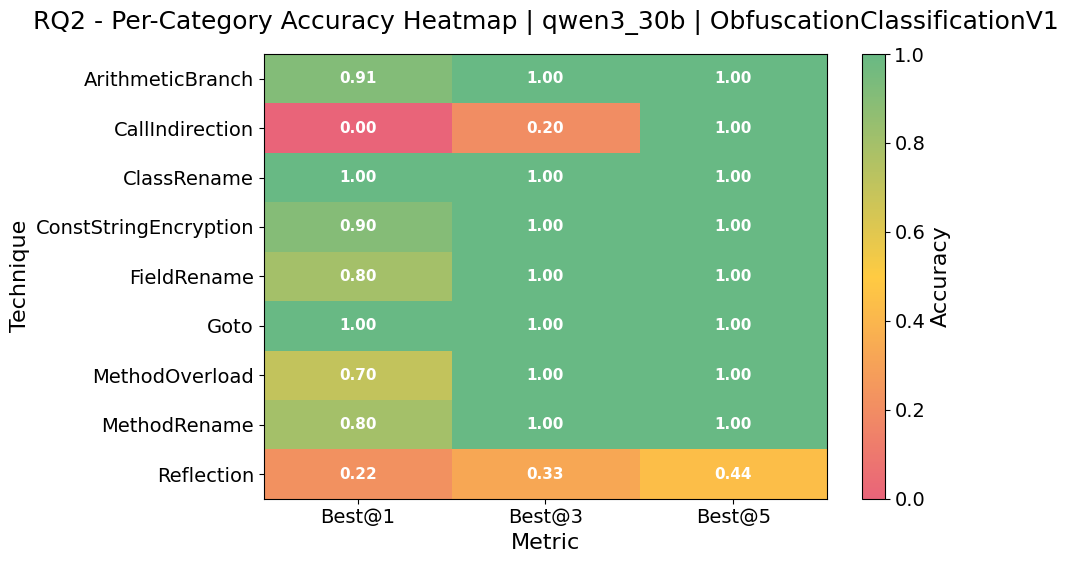

In [15]:
# One heatmap per prompt-model combination, using the category-level fullResultsDF.
for _, combinationRow in plotCombinationsDf.iterrows():
	modelName = combinationRow["model"]
	promptId  = combinationRow["prompt"]
	plotDf    = fullLongDf[(fullLongDf["model"] == modelName) & (fullLongDf["prompt"] == promptId)].copy()
	if plotDf.empty:
		continue

	heatmapDf = plotDf.pivot(index = "category", columns = "metricLabel", values = "accuracy")
	heatmapDf = heatmapDf.reindex(index = OBFUSCATION_TECHNIQUES, columns = METRIC_LABELS)

	fig, ax = plt.subplots(figsize = (10, max(4, len(heatmapDf.index) * 0.65)))
	image = ax.imshow(heatmapDf.values, cmap = TRAFFIC_LIGHT_CMAP, vmin = 0, vmax = 1, aspect = "auto")
	ax.set_title("RQ2 - Per-Category Accuracy Heatmap | {} | {}".format(modelName, promptId), pad = TITLE_PAD)
	ax.set_xlabel("Metric")
	ax.set_ylabel("Technique")
	ax.set_xticks(range(len(heatmapDf.columns)))
	ax.set_xticklabels(heatmapDf.columns)
	ax.set_yticks(range(len(heatmapDf.index)))
	ax.set_yticklabels(heatmapDf.index)

	for rowIndex in range(len(heatmapDf.index)):
		for columnIndex in range(len(heatmapDf.columns)):
			cellValue = heatmapDf.iloc[rowIndex, columnIndex]
			cellText = "-" if pd.isna(cellValue) else "{:.2f}".format(cellValue)
			ax.text(columnIndex, rowIndex, cellText, ha = "center", va = "center", color = "white" if not pd.isna(cellValue) else "black", fontsize = 11, fontweight = "bold")

	colorBar = fig.colorbar(image, ax = ax)
	colorBar.set_label("Accuracy")
	plt.tight_layout()
	plt.show()


#### 🔥 E] LLM x Technique Heatmaps

⭕ Combination:
- [PROMPT] x [Best@K]

⭕ Showing:
- X Axis: [LLM]
- Y Axis: [Technique]
- Cell: [Accuracy]

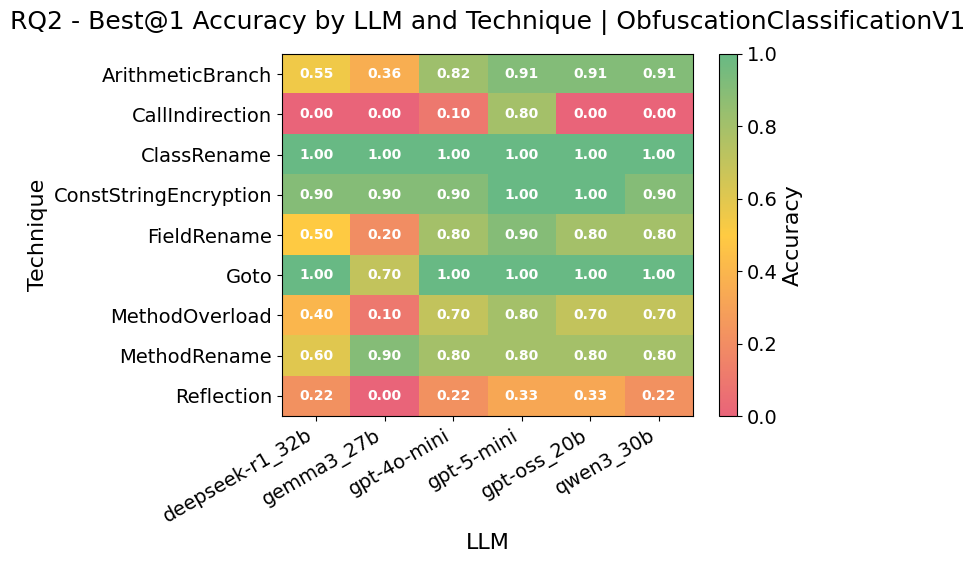

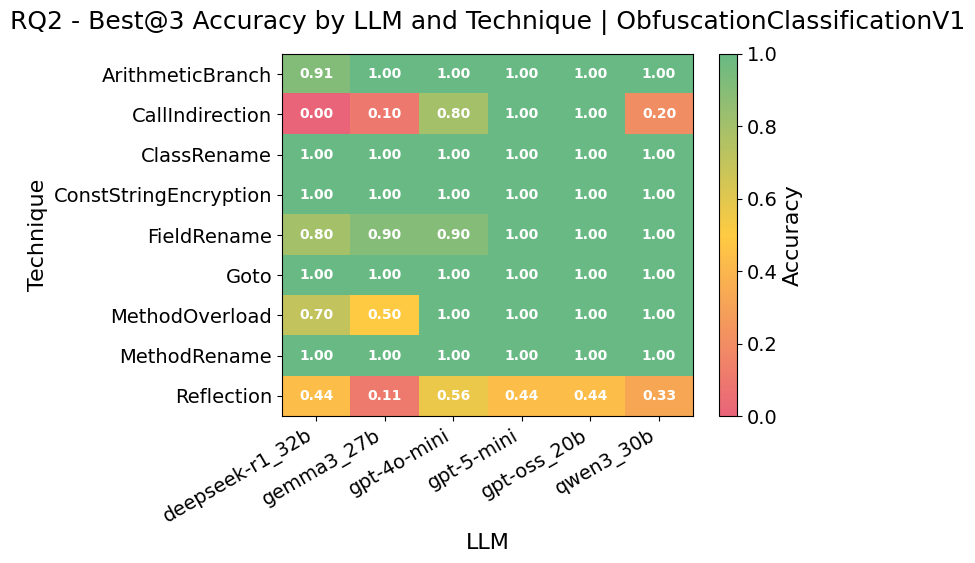

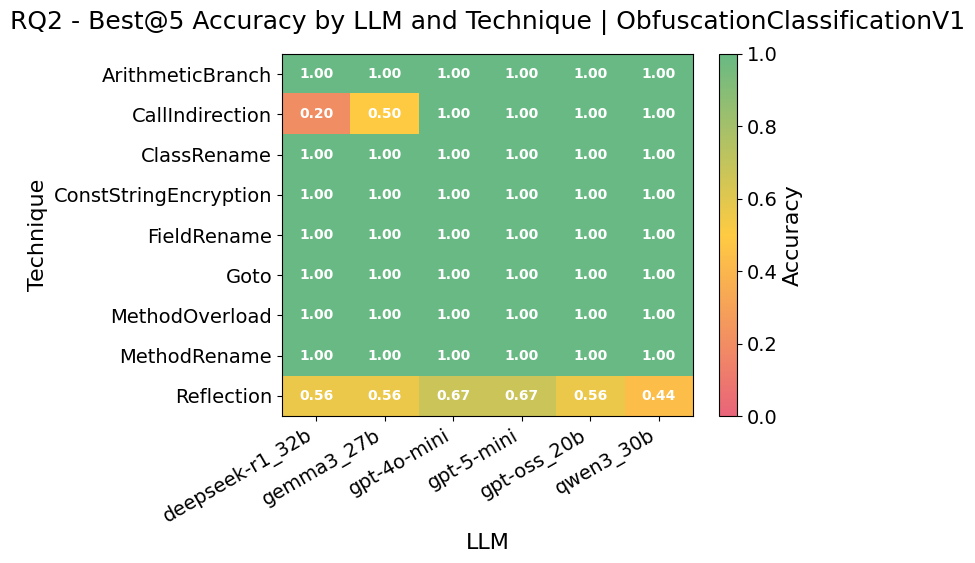

In [16]:
# One LLM-by-technique heatmap per prompt and metric.
for promptId in PROMPTS:
	promptDf = fullLongDf[fullLongDf["prompt"] == promptId].copy()
	if promptDf.empty:
		continue

	availableModels = [modelName for modelName in MODELS if modelName in promptDf["model"].unique()]
	for metricColumn in METRIC_COLUMNS:
		metricPlotDf = promptDf[promptDf["metric"] == metricColumn].copy()
		heatmapDf = metricPlotDf.pivot(index = "category", columns = "model", values = "accuracy")
		heatmapDf = heatmapDf.reindex(index = OBFUSCATION_TECHNIQUES, columns = availableModels)

		fig, ax = plt.subplots(figsize = (max(8, len(availableModels) * 1.35), max(4, len(heatmapDf.index) * 0.65)))
		image = ax.imshow(heatmapDf.values, cmap = TRAFFIC_LIGHT_CMAP, vmin = 0, vmax = 1, aspect = "auto")
		ax.set_title("RQ2 - {} Accuracy by LLM and Technique | {}".format(METRIC_LABEL_BY_COLUMN[metricColumn], promptId), pad = TITLE_PAD)
		ax.set_xlabel("LLM")
		ax.set_ylabel("Technique")
		ax.set_xticks(range(len(heatmapDf.columns)))
		ax.set_xticklabels(heatmapDf.columns, rotation = 30, ha = "right")
		ax.set_yticks(range(len(heatmapDf.index)))
		ax.set_yticklabels(heatmapDf.index)

		for rowIndex in range(len(heatmapDf.index)):
			for columnIndex in range(len(heatmapDf.columns)):
				cellValue = heatmapDf.iloc[rowIndex, columnIndex]
				cellText = "-" if pd.isna(cellValue) else "{:.2f}".format(cellValue)
				ax.text(columnIndex, rowIndex, cellText, ha = "center", va = "center", color = "white" if not pd.isna(cellValue) else "black", fontsize = 10, fontweight = "bold")

		colorBar = fig.colorbar(image, ax = ax)
		colorBar.set_label("Accuracy")
		plt.tight_layout()
		plt.show()


##### End 🏁

In [17]:
endTime = datetime.datetime.now()
print("\nEND:  {}".format(endTime.strftime("%Y-%m-%d %H:%M:%S")))

totalTime = endTime - initTime
hours = totalTime.total_seconds() // 3600
minutes = (totalTime.total_seconds() % 3600) // 60
print("Time: {:02d} hours and {:02d} minutes [{:02d} seconds]".format(int(hours), int(minutes), int(totalTime.total_seconds())))


END:  2026-06-11 11:12:55
Time: 00 hours and 00 minutes [03 seconds]
